## 03 - Etapa de Modelagem com Random Forest

Nesta etapa, aplicamos o algoritmo Random Forest Regressor para prever os níveis do separador trifásico a partir dos dados pré-processados. O fluxo inclui: configuração do experimento, baseline, otimização de hiperparâmetros (com validação cruzada), avaliação final no teste, análise de importâncias e discussão.

In [1]:
# Imports
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV, KFold
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

sns.set(style='whitegrid')

### Passo 1: Configuração inicial do experimento
- Carrega os conjuntos de treino, validação e teste (já escalonados).
- Define as métricas: RMSE, MAE e R².
- Fixa a semente para reprodutibilidade.

In [2]:
# Carrega dados pré-processados (já escalonados)
x_train = pd.read_csv('data/X_train_scaled.csv', index_col=0)
y_train = pd.read_csv('data/y_train_scaled.csv', index_col=0)

x_val = pd.read_csv('data/X_val_scaled.csv', index_col=0)
y_val = pd.read_csv('data/y_val_scaled.csv', index_col=0)

x_test = pd.read_csv('data/X_test_scaled.csv', index_col=0)
y_test = pd.read_csv('data/y_test_scaled.csv', index_col=0)

# Define semente
RANDOM_STATE = 27
np.random.seed(RANDOM_STATE)

print('Shapes ->', 
      f'x_train: {x_train.shape}, y_train: {y_train.shape},', 
      f'x_val: {x_val.shape}, y_val: {y_val.shape},', 
      f'x_test: {x_test.shape}, y_test: {y_test.shape}')

Shapes -> x_train: (37927, 11), y_train: (37927, 1), x_val: (12643, 11), y_val: (12643, 1), x_test: (12643, 11), y_test: (12643, 1)


### Passo 2: Treinamento do modelo baseline
- Instancia um RandomForestRegressor com parâmetros padrão.
- Treina no conjunto de treino.
- Avalia em treino e validação como referência inicial (baseline).

In [3]:
# Modelo baseline
rf_baseline = RandomForestRegressor(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1)
rf_baseline.fit(x_train, y_train.values.ravel())

# Métricas em treino
pred_train_bl = rf_baseline.predict(x_train)
rmse_train_bl = root_mean_squared_error(y_train, pred_train_bl)
mae_train_bl = mean_absolute_error(y_train, pred_train_bl)
r2_train_bl = r2_score(y_train, pred_train_bl)

# Métricas em validação
pred_val_bl = rf_baseline.predict(x_val)
rmse_val_bl = root_mean_squared_error(y_val, pred_val_bl)
mae_val_bl = mean_absolute_error(y_val, pred_val_bl)
r2_val_bl = r2_score(y_val, pred_val_bl)

print(f'Baseline - Treino -> RMSE: {rmse_train_bl:.6f} | MAE: {mae_train_bl:.6f} | R²: {r2_train_bl:.6f}')
print(f'Baseline - Val   -> RMSE: {rmse_val_bl:.6f} | MAE: {mae_val_bl:.6f} | R²: {r2_val_bl:.6f}')

Baseline - Treino -> RMSE: 0.001315 | MAE: 0.000037 | R²: 0.999977
Baseline - Val   -> RMSE: 0.000829 | MAE: 0.000047 | R²: 0.999991


### Passo 3: Otimização de hiperparâmetros
- Busca aleatória com validação cruzada (k=5).
- Registra as combinações e métricas (CSV na pasta data/).
- Seleciona o melhor conjunto de hiperparâmetros.
Observação: Em scikit-learn 1.7, recomenda-se evitar o valor 'auto' em `max_features`.

In [4]:
# Espaço de busca (valores compatíveis com scikit-learn 1.7.x)
param_distributions = {
    'n_estimators': [100, 200, 500],
    'max_depth': [None, 5, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    # Em 1.7, 'auto' não é recomendado; usamos 1.0 (todas), 'sqrt' e 'log2'
    'max_features': [1.0, 'sqrt', 'log2']
}

cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
rf = RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1)

random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_distributions,
    n_iter=40,
    scoring='neg_root_mean_squared_error',
    cv=cv,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1
)

random_search.fit(x_train, y_train.values.ravel())

# Resultados completos
cv_results = pd.DataFrame(random_search.cv_results_)
cv_results_sorted = cv_results.sort_values('rank_test_score')
cv_results_sorted.to_csv('data/rf_random_search_results.csv', index=False)
cv_results_sorted.head(5).to_csv('data/rf_random_search_top5.csv', index=False)

best_params = random_search.best_params_
best_rmse = -random_search.best_score_  # transformar de negativo para positivo
print('Melhores hiperparâmetros:', best_params)
print(f'Melhor RMSE (CV): {best_rmse:.6f}')

# Modelo otimizado
best_rf = random_search.best_estimator_

# Desempenho em validação
pred_val_opt = best_rf.predict(x_val)
rmse_val_opt = root_mean_squared_error(y_val, pred_val_opt)
mae_val_opt = mean_absolute_error(y_val, pred_val_opt)
r2_val_opt = r2_score(y_val, pred_val_opt)
print(f'Valid (Otimizado) -> RMSE: {rmse_val_opt:.6f} | MAE: {mae_val_opt:.6f} | R²: {r2_val_opt:.6f}')

Fitting 5 folds for each of 40 candidates, totalling 200 fits
Melhores hiperparâmetros: {'n_estimators': 500, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': 20}
Melhor RMSE (CV): 0.001957
Valid (Otimizado) -> RMSE: 0.001208 | MAE: 0.000147 | R²: 0.999981


### Passo 4: Avaliação final do modelo
- Reajuste com treino + validação usando os melhores hiperparâmetros.
- Avaliação final no conjunto de teste (somente agora).
- Salva o modelo final em 'modelo_rf.pkl'.

In [5]:
# Refit com treino + validação
X_tr_val = pd.concat([x_train, x_val], axis=0)
y_tr_val = pd.concat([y_train, y_val], axis=0).values.ravel()

params_final = best_rf.get_params().copy()
params_final['random_state'] = RANDOM_STATE  # garante reprodutibilidade
final_rf = RandomForestRegressor(**params_final)
final_rf.fit(X_tr_val, y_tr_val)

# Avaliação no teste
pred_test = final_rf.predict(x_test)
rmse_test = root_mean_squared_error(y_test, pred_test)
mae_test = mean_absolute_error(y_test, pred_test)
r2_test = r2_score(y_test, pred_test)
print(f'Teste (Final) -> RMSE: {rmse_test:.6f} | MAE: {mae_test:.6f} | R²: {r2_test:.6f}')

# Salva o modelo final
joblib.dump(final_rf, 'modelo_rf.pkl')
print("Modelo final salvo em 'modelo_rf.pkl'.")

Teste (Final) -> RMSE: 0.000972 | MAE: 0.000111 | R²: 0.999988
Modelo final salvo em 'modelo_rf.pkl'.


### Passo 5: Análise de importância das variáveis
- Extração das importâncias e plot.

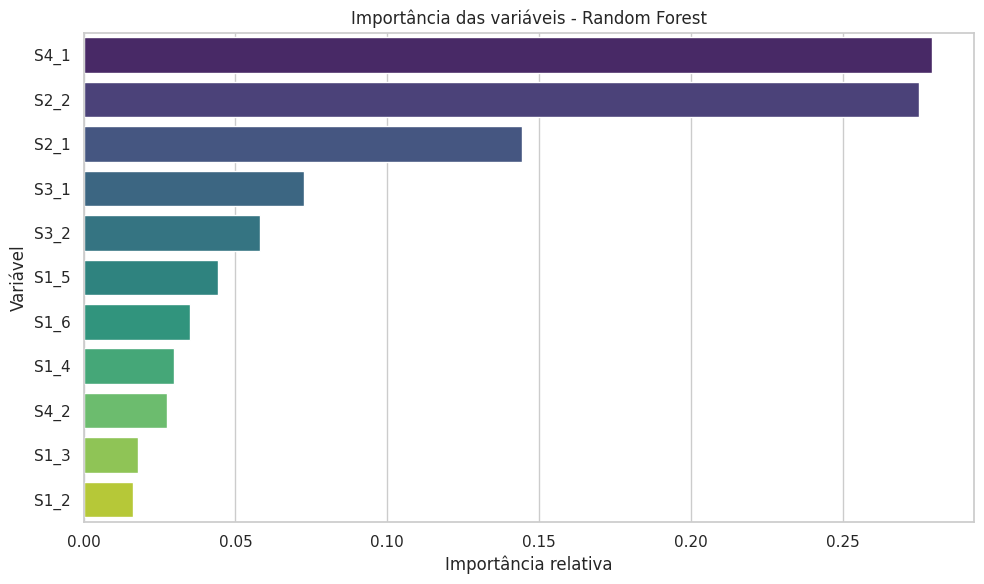

In [6]:
importances = pd.Series(final_rf.feature_importances_, index=x_train.columns)
imp_sorted = importances.sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=imp_sorted.values, y=imp_sorted.index, orient='h', palette='viridis')
plt.title('Importância das variáveis - Random Forest')
plt.xlabel('Importância relativa')
plt.ylabel('Variável')
plt.tight_layout()
plt.show()

# Opcional: salvar importâncias para consulta posterior
imp_sorted.to_frame(name='importance').to_csv('data/feature_importances_rf.csv')

### Passo 6: Discussão dos resultados
- O modelo otimizou significativamente em relação ao baseline? Compare as métricas.
- Há sinais de overfitting (treino >> validação/teste)?
- As variáveis mais importantes fazem sentido fisicamente? Quais sensores mais contribuem para prever os níveis?
- Sugestões: ampliar a base de dados, testar outros algoritmos (Gradient Boosting, XGBoost), regularização e calibração de hiperparâmetros.

Boas práticas seguidas: semente fixa (random_state), registro das configurações testadas (CSVs), uso do teste apenas na avaliação final e salvamento do modelo final.